In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from scipy.stats import pearsonr
plt.rcParams['font.family']='ARIAL'
plt.rcParams['font.family']='ARIAL'
plt.rcParams['pdf.fonttype'] = 'truetype'
plt.rcParams["mathtext.rm"] = "ARIAL"
plt.rcParams['mathtext.it'] = 'ARIAL'
plt.rcParams['mathtext.bf'] = 'ARIAL'
plt.rcParams['font.sans-serif']=['ARIAL']
plt.rcParams['axes.unicode_minus'] =False
plt.rcParams['axes.linewidth']=0.5 # 边的宽
plt.rcParams['axes.labelsize']=7
plt.rcParams['axes.titlesize']=7
plt.rcParams['xtick.labelsize']=6
plt.rcParams['ytick.labelsize']=6
plt.rcParams['legend.fontsize']=6.5
plt.rcParams['legend.title_fontsize'] = 7
plt.rcParams['xtick.major.size']= 3 # 最大刻度大小
plt.rcParams['xtick.minor.size']= 1.5 # 最小刻度大小
plt.rcParams['xtick.major.width']= 0.5 # 最大刻度宽度
plt.rcParams['xtick.minor.width']= 0.4 # 最小刻度宽度
plt.rcParams['ytick.major.size']= 3 # 最大刻度大小
plt.rcParams['ytick.minor.size']= 1.5 # 最小刻度大小
plt.rcParams['ytick.major.width']= 0.45 # 最大刻度宽度
plt.rcParams['ytick.minor.width']= 0.4 # 最小刻度宽度

In [2]:
df_gene=pd.read_csv("/wanglab1/gangx/data2/HLF/gencode.v40.pri.annotation_gene.bed",sep="\t",header=None)
df_gene["GENEID"]=df_gene[3].apply(lambda x:x.split(":")[0])
df_gene["GENESYMBOL"]=df_gene[3].apply(lambda x:x.split(":")[1])
df_gene=df_gene[~df_gene[4].isin({"miRNA","snoRNA","misc_RNA","scaRNA","ribozyme","scRNA","vault_RNA","snRNA","sRNA","rRNA","rRNA_pseudogene","Mt_rRNA","Mt_tRNA",'TEC'})].copy()

In [3]:
df_at=pd.read_csv("/home/gangx/data/HLF/250827/result/AGO_vs_EPN_DESeq2.csv")

In [4]:
df_norm=pd.read_csv("/home/gangx/data/HLF/250827/result/normalized_counts_spikein.csv")

In [5]:
df_norm=df_norm[df_norm['Unnamed: 0'].isin(df_gene["GENEID"])].copy()

In [6]:
for i in df_norm.columns[1:]:
    df_norm[i]=df_norm[i]/df_norm[i].sum()*1e6

In [7]:
df_at.columns

Index(['Unnamed: 0', 'Row.names', 'baseMean', 'log2FoldChange', 'lfcSE',
       'stat', 'pvalue', 'padj', 'gene_symbol', 'gene_type'],
      dtype='object')

In [8]:
set_target=set(df_at[(df_at['padj']<0.05)&(df_at['log2FoldChange']>2)]['Row.names'])&set(df_norm[df_norm[['AGO_1','AGO_2']].mean(1)>50]['Unnamed: 0'])&set(df_gene['GENEID'])

In [33]:
df_at.set_index("Row.names",inplace=True)

In [35]:
df_at['CPM']=df_norm.set_index("Unnamed: 0")[['AGO_1','AGO_2']].mean(1)

In [39]:
df_at.loc[list(set_target)].sort_values(by="padj").to_csv("AGO2_table.csv")

In [9]:
df_mi=pd.read_csv("/home/gangx/data/HLF/250829/smallRNA-seq_mature.csv")

In [10]:
for i in df_mi.columns[2:]:
    df_mi[i]=df_mi[i]/sum(df_mi[i])*1e6

In [11]:
df_mi['AC']=df_mi[["AC-1","AC-2","AC-3"]].mean(1)
df_mi['AGO2']=df_mi[["AGO-1","AGO-2"]].mean(1)

In [12]:
df_mi.sort_values("AC",ascending=False,inplace=True)

In [12]:
df_mi.sort_values("AGO2",ascending=False,inplace=True)

In [13]:
set(df_mi.head(10)['Unnamed: 0'])

{'hsa-miR-10a-5p',
 'hsa-miR-10b-5p',
 'hsa-miR-148a-3p',
 'hsa-miR-20a-5p',
 'hsa-miR-221-3p',
 'hsa-miR-25-3p',
 'hsa-miR-3529-3p',
 'hsa-miR-378a-3p',
 'hsa-miR-7-5p',
 'hsa-miR-92a-3p'}

In [15]:
df_tgsc_hsa2_8mer=pd.read_csv("targetScan_8mer_hsa.txt",sep="\t")

In [13]:
df_tgsc_hsa2=pd.read_csv("targetScan_default_hsa.txt",sep="\t")

In [16]:
df_tgsc_hsa2_conserved=df_tgsc_hsa2[df_tgsc_hsa2['Total num conserved sites']>0]

In [17]:
df_tgsc_hsa2.columns

Index(['Unnamed: 0', 'Transcript ID', 'Gene Symbol', 'miRNA family',
       'Species ID', 'Total num conserved sites',
       'Number of conserved 8mer sites', 'Number of conserved 7mer-m8 sites',
       'Number of conserved 7mer-1a sites', 'Total num nonconserved sites',
       'Number of nonconserved 8mer sites',
       'Number of nonconserved 7mer-m8 sites',
       'Number of nonconserved 7mer-1a sites', 'Number of 6mer sites',
       'Representative miRNA', 'Total context++ score',
       'Cumulative weighted context++ score', 'Aggregate PCT',
       'Predicted occupancy - low miRNA', 'Predicted occupancy - high miRNA',
       'Predicted occupancy - transfected miRNA', 'gene_id', 'transcript_id',
       'GENESYMBOL'],
      dtype='object')

In [18]:
len(set(df_tgsc_hsa2_8mer[(df_tgsc_hsa2_8mer['Representative miRNA'].isin(set(df_mi.head(10)['Unnamed: 0'])))]["GENESYMBOL"]))

3034

In [19]:
from scipy.stats import fisher_exact
from matplotlib_venn import venn2,venn3
def Exporter_venn2(ax,set_list,label_list,color_list=['r','y','b'],alpha=0.45,bgsize=20000,title=None):
    out = venn2(subsets = set_list,
            set_labels=label_list,
            set_colors=color_list,
            alpha=alpha,
            ax=ax)
    for text in out.set_labels:
        text.set_fontsize(7)
    for text in out.subset_labels:
        if text:
            text.set_fontsize(7)
    fe=fisher_exact([ [len(set_list[1]&set_list[0]), len(set_list[1])],[len(set_list[0]), bgsize]])
    ax.text(0,-1.15,"EnrichmentFold = %.3g\n$\mathit{P}$ = %.3g"%(fe[0],fe[1]),va="center",ha="center",fontsize=7)
    ax.set_title(title)

<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/home/tmp/ipykernel_99832/3693646962.py:15: SyntaxWarning: invalid escape sequence '\m'
  ax.text(0,-1.15,"EnrichmentFold = %.3g\n$\mathit{P}$ = %.3g"%(fe[0],fe[1]),va="center",ha="center",fontsize=7)


In [20]:
df_cell=pd.read_csv("/home/gangx/data/HLF/251004/rawCounts.tsv",sep="\t",header=1)

In [21]:
df_cell=df_cell[df_cell['Geneid'].isin(set(df_gene["GENEID"]))].copy()

In [22]:
df_cell.columns=['Geneid', 'Chr', 'Start', 'End', 'Strand', 'Length','FMR1-Cell-1','FMR1-Cell-2','IGF2-Cell-1','IGF2-Cell-2','Mock-Cell-1','Mock-Cell-2','PABPC1-Cell-1','PABPC1-Cell-2']

In [23]:
for i in df_cell.columns[6:]:
    df_cell[i]=df_cell[i]/df_cell["Length"]
    df_cell[i]=df_cell[i]/sum(df_cell[i])*1e6

In [24]:
express_set=set(df_cell[df_cell[['Mock-Cell-1','Mock-Cell-2']].mean(1)>10]["Geneid"])

In [25]:
express_set1=set(df_cell[df_cell[['Mock-Cell-1','Mock-Cell-2']].mean(1)>1]["Geneid"])

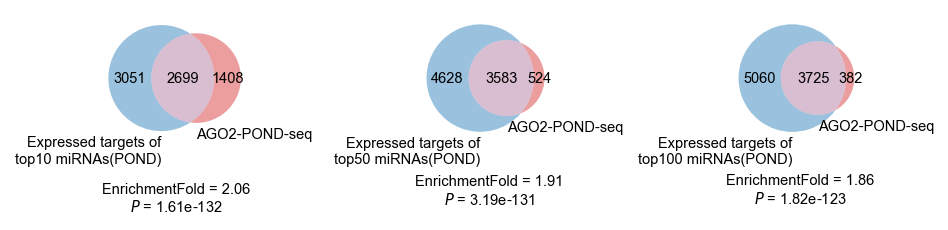

In [30]:
fig,axs=plt.subplots(1,3, figsize=(7,1.1),dpi=150)
plt.suptitle('',fontsize=7)
Exporter_venn2(ax=axs[0],set_list=[set(df_gene[df_gene['GENEID'].isin(express_set)]['GENESYMBOL'])&set(df_tgsc_hsa2[(df_tgsc_hsa2['Representative miRNA'].isin(set(df_mi.head(10)['Unnamed: 0'])))]["GENESYMBOL"]),
                                     set(df_gene[df_gene['GENEID'].isin(set_target)]['GENESYMBOL'])],
            label_list=['Expressed targets of\ntop10 miRNAs(POND)','AGO2-POND-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1],set_list=[set(df_gene[df_gene['GENEID'].isin(express_set)]['GENESYMBOL'])&set(df_tgsc_hsa2[(df_tgsc_hsa2['Representative miRNA'].isin(set(df_mi.head(50)['Unnamed: 0'])))]["GENESYMBOL"]),
                                     set(df_gene[df_gene['GENEID'].isin(set_target)]['GENESYMBOL'])],
            label_list=['Expressed targets of\ntop50 miRNAs(POND)','AGO2-POND-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[2],set_list=[set(df_gene[df_gene['GENEID'].isin(express_set)]['GENESYMBOL'])&set(df_tgsc_hsa2[(df_tgsc_hsa2['Representative miRNA'].isin(set(df_mi.head(100)['Unnamed: 0'])))]["GENESYMBOL"]),
                                     set(df_gene[df_gene['GENEID'].isin(set_target)]['GENESYMBOL'])],
            label_list=['Expressed targets of\ntop100 miRNAs(POND)','AGO2-POND-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.62, hspace=0.55)
plt.savefig("AGO2_miRNAtargets_all(POND).pdf",bbox_inches = 'tight', pad_inches = 0.1)